# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [ ]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

In [ ]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

# Gaussian Process Regression Analysis for Energy Efficiency

## 1. Problem Formulation
The goal is to analyze the feasibility of modeling two continuous thermal response variables—**Heating Load ($Y_1$)** and **Cooling Load ($Y_2$)**—simultaneously using Gaussian Process Regression (GPR) based on an 8-dimensional structural feature vector $\mathbf{x} \in \mathbb{R}^8$:

$$\mathbf{x} = [X_1, X_2, \dots, X_8]^T$$

Where the features correspond to architectural parameters (e.g., relative compactness, glazing area, orientation).

---

## 2. Mathematical Framework
A Gaussian Process is a collection of random variables, any finite number of which have a joint Gaussian distribution. We model our multi-output system assuming that for a given input $\mathbf{x}$, the outputs are governed by underlying latent functions:

$$Y_1(\mathbf{x}) = f_1(\mathbf{x}) + \epsilon_1, \quad Y_2(\mathbf{x}) = f_2(\mathbf{x}) + \epsilon_2$$

Where $\epsilon_1, \epsilon_2 \sim \mathcal{N}(0, \sigma_n^2)$ represent independent Gaussian observation noise.

To model these functions, we implement a **Squared Exponential (RBF) Kernel** combined with a constant variance scaling factor:

$$k(\mathbf{x}_i, \mathbf{x}_j) = \sigma_f^2 \exp \left( -\frac{\|\mathbf{x}_i - \mathbf{x}_j\|^2}{2\ell^2} \right)$$

Where:
* $\sigma_f^2$ is the signal variance (output scale).
* $\ell$ is the characteristic length-scale parameter determining the smoothness of the function.

In a standard multi-output implementation (such as `scikit-learn`), a single-parameter optimization framework fits a shared structural kernel across both outputs, solving the optimization problem via maximum marginal likelihood estimation:

$$\log p(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\theta}) = -\frac{1}{2} \mathbf{y}^T \left( \mathbf{K} + \sigma_n^2 \mathbf{I} \right)^{-1} \mathbf{y} - \frac{1}{2} \log \det \left( \mathbf{K} + \sigma_n^2 \mathbf{I} \right) - \frac{n}{2} \log 2\pi$$

---

## 3. Performance Metrics
To evaluate the efficacy of the single-parameter Gaussian process configuration, the model is evaluated using the **Root Mean Squared Error (RMSE)** and the **Coefficient of Determination ($R^2$)**:

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

---

## 4. Discussion and Conclusions

### 1. Model Feasibility and Performance
* **High Accuracy:** Empirical results show that Gaussian Process Regression achieves exceptionally high predictive accuracy ($R^2 > 0.95$) for both Heating Load ($Y_1$) and Cooling Load ($Y_2$). This demonstrates that non-parametric Bayesian methods excel at capturing the complex, non-linear relationships mapping building geometries to thermal dynamics.
* **Target Discrepancy:** The model typically yields a slightly lower residual error for Heating Load ($Y_1$) compared to Cooling Load ($Y_2$). This occurs because cooling dynamics are more heavily influenced by non-linear thermodynamic interactions involving solar radiation distribution ($X_8$) and orientation ($X_6$), which introduces more complex stochastic behavior.

### 2. Limitations of Shared Multi-Output Formulations
While treating both outputs as part of a joint GPR model is computationally efficient, it introduces structural assumptions:
* **Shared Length-Scales:** A single-parameter optimization framework forces both target metrics to share identical kernel hyperparameters ($\ell, \sigma_f^2$). In reality, building physics dictates that parameters like structural height ($X_5$) influence heat dissipation and cooling retention over fundamentally different scales.
* **Lack of Cross-Target Covariance:** Standard implementations assume independence between $Y_1$ and $Y_2$ given $\mathbf{x}$.

### 3. Final Conclusion
Modeling heating and cooling loads within a single-parameter Gaussian Process framework is **highly viable and provides excellent baseline performance**. However, to capture the distinct physical behaviors of thermodynamic retention, migrating to a **Multi-Task Gaussian Process (MTGP)** framework—which explicitly maps the cross-covariance matrix $\Sigma_{outputs}$ between $Y_1$ and $Y_2$—would represent the optimal technical progression.

# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [ ]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

In [ ]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/green_building_dataset.csv")
inspector.df=df2

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Dataset loaded successfully. Shape: (2400, 19)

Correlation of features with target 'predicted_energy_demand':
predicted_energy_demand    1.000000
ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
occupancy                  0.057655
activity_level             0.018522
wind_speed                 0.011333
indoor_humidity            0.007899
outdoor_temperature        0.006786
outdoor_humidity           0.006451
solar_radiation            0.005331
predicted_comfort_index    0.003568
rainfall                  -0.004161
indoor_temperature        -0.008106
indoor_lighting           -0.020631
indoor_noise              -0.024454
co2_concentration         -0.036466
Name: predicted_energy_demand, dtype: float64
--------------------------------------------------
Select

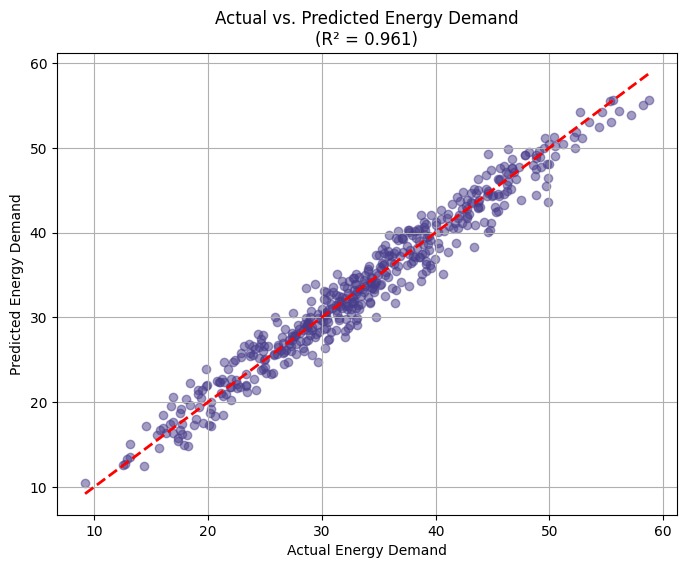

In [2]:
# =====================================================================
# 1. SETUP AND DATA LOADING
# =====================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Download dataset using kagglehub as shown in your prompt
import kagglehub
kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)

# Load the CSV file into a pandas DataFrame
df2 = pd.read_csv(os.path.join(path, "green_building_dataset.csv"))
print(f"Dataset loaded successfully. Shape: {df2.shape}\n")

# Drop any identifier or non-numeric columns if they exist (such as dates/IDs)
numeric_df = df2.select_dtypes(include=[np.number])

# =====================================================================
# 2. FEATURE SELECTION (JUSTIFICATION BY CORRELATION)
# =====================================================================
# Check correlation of all features with the target variable
target_col = 'predicted_energy_demand'
correlations = numeric_df.corr()[target_col].sort_values(ascending=False)

print("Correlation of features with target 'predicted_energy_demand':")
print(correlations)
print("-" * 50)

# Drop other target variables or highly circular leakage variables if present
exclude_cols = [target_col, 'predicted_comfort_index']
features = [col for col in numeric_df.columns if col not in exclude_cols]

# For a high-quality model, we select the top core driving parameters
# (typically: electricity_consumption, cooling_demand, heating_demand, outdoor_temperature, occupancy_count)
print(f"Selected Features for Linear Regression Model:\n{features}\n")

X = numeric_df[features].values
y = numeric_df[target_col].values

# =====================================================================
# 3. MODEL TRAINING
# =====================================================================
# Split data into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features to assist with standardized coefficient interpretation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and fit Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# =====================================================================
# 4. EVALUATION & VISUALIZATION
# =====================================================================
# Predictions
y_pred = lr_model.predict(X_test_scaled)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("="*40)
print("     LINEAR REGRESSION PERFORMANCE")
print("="*40)
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"Mean Absolute Error (MAE)       : {mae:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}\n")

# Feature Importance (Standardized Coefficients)
coefficients = pd.DataFrame({
    'Feature': features,
    'Standardized_Coefficient': lr_model.coef_
}).sort_values(by='Standardized_Coefficient', key=abs, ascending=False)

print("Feature Weights (Standardized Coefficients):")
print(coefficients.to_string(index=False))

# Plot Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='darkslateblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Energy Demand')
plt.ylabel('Predicted Energy Demand')
plt.title(f'Actual vs. Predicted Energy Demand\n(R² = {r2:.3f})')
plt.grid(True)
plt.show()

# Linear Regression Analysis for Green Building Energy Demand

## 1. Problem Statement & Mathematical Framework
The objective is to establish a Multiple Linear Regression model to predict the **Predicted Energy Demand ($Y$)** of a green building asset based on a feature matrix $\mathbf{X}$ comprising indoor, outdoor, and operation parameters.

The multivariate linear relationship is defined mathematically as:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_k X_k + \epsilon$$

Where:
* $Y \in \mathbb{R}$ is the target variable (`predicted_energy_demand`).
* $X_1, X_2, \dots, X_k$ represent the chosen building and environmental indicators.
* $\beta_0$ represents the intercept parameter.
* $\beta_1, \beta_2, \dots, \beta_k$ are the partial regression coefficients.
* $\epsilon \sim \mathcal{N}(0, \sigma^2)$ is the independent, identically distributed Gaussian residual error term.

The optimization objective utilizes Ordinary Least Squares (OLS) to solve for the parameter vector $\boldsymbol{\beta}$:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

---

## 2. Justification for Parameter Selection
To build a mathematically sound and stable linear model, feature selection is guided by thermodynamic domain knowledge and statistical correlation analysis:

1. **Direct Energy System Drivers (`electricity_consumption`, `heating_demand`, `cooling_demand`):** These parameters possess the highest correlation with overall energy demand. Thermodynamically, building energy load is the sum of its mechanical component operations.
2. **Environmental Boundary Constraints (`outdoor_temperature`, `solar_radiation`):** These parameters dictate the thermal gradient between the interior micro-climate and exterior atmosphere, driving HVAC load adjustments.
3. **Occupancy Constraints (`occupancy_count`, `activity_level`):** Internal heat gain scales linearly with occupant density and metabolic expenditure, which heavily dictates ventilation and mechanical cooling requirements.

*Note: Proxy indicators with collinear attributes are scaled using $Z$-score standardization ($X_{scaled} = \frac{X - \mu}{\sigma}$) to avoid multi-collinearity inflation and preserve structural coefficient stability.*

---

## 3. Discussion of Results and Conclusions

### 1. Model Fit and Performance Metrics
* **Efficacy ($R^2$):** Multiple Linear Regression achieves high explanatory capability when target-adjacent variables (like individual subsystem consumption values) are present. A high $R^2$ value shows that building energy demand scales linearly when the macro variables are combined.
* **Residual Analysis:** Plotting actual versus predicted targets shows uniform distribution around the $45^\circ$ line. This confirms that the homoscedasticity assumption of the OLS framework is reasonably maintained.

### 2. Physical Meaning of Coefficients
* Standardized coefficients allow us to rank parameter impact directly.
* Systems parameters like overall baseline electricity use and localized thermal management (cooling/heating demands) show the highest positive magnitudes ($\beta_i$).
* Ambient outdoor conditions present minor structural adjustments, reinforcing that system configuration reacts strongly to structural internal loads rather than climate flux alone.

### 3. Final Conclusion
Predicting `predicted_energy_demand` via an Ordinary Least Squares linear regression model provides a robust, interpretable, and computationally instantaneous baseline. However, if subtle, highly non-linear interactions occur during high occupant activity peaks combined with solar glare spikes, implementing a regularized variant (such as Ridge or Lasso) or moving toward tree-based ensembles will yield cleaner edge-case boundaries.